In [1]:
import fitness_landscape as fl
import os
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path
import networkx as nx
from tqdm import tqdm
from scipy.stats import linregress, zscore
from Bio import SeqIO
import matplotlib.pyplot as plt
import Bio.PDB
import py3Dmol

### Catalytic landscape

In [42]:
# Read in aligned sequences
record_dict = {seq.id : seq.seq for seq in SeqIO.parse('../data_files/adk_orthologues/175_adk_org_aligned.fasta', 'fasta')}

# Read in data
df_intersect = pd.read_csv('../data_files/adk_orthologues/adk_ml_dataset.csv')
df_intersect.dropna(inplace=True)

# Map aligned sequences
df_intersect['aligned_sequence'] = df_intersect['org_name'].map(record_dict)



sequences = [fl.BaseNumpySequence(sequence) for sequence in df_intersect['aligned_sequence']]
fitness_km = np.array(df_intersect['log10_km'])
fitness_kcat = np.array(df_intersect['log10_kcat'])
fitness_temp = np.array(df_intersect['temperature'])

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="knn",
    k=knn_k,
    backend="balltree",
    _compute_hamming_edges=False
)

# landscape = fl.FitnessLandscape.build(
#     sequences,
#     graph="hamming",
# )



f_km_std = zscore(fitness_km)
f_kcat_std = zscore(fitness_kcat)
f_temp_std = zscore(fitness_temp)

# Attach and analyze km
landscape.attach(name="km_fitness_std", values=f_km_std, dtype="numeric")

# Attach and analyze kcat
landscape.attach(name="kcat_fitness_std", values=f_kcat_std, dtype="numeric")

# Attach and analyze growth temperature
landscape.attach(name="temp_fitness_std", values=f_temp_std, dtype="numeric")

# Get landscape components.
landscape = landscape.get_components()[0]

eigenvals, eigenvecs = fl.transforms.eigenmode_decomposition(landscape)

# Compute ruggedness on km 
landscape.view("km_fitness_std")
tmap_res_km = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, method="profile"
)
km_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)

# Compute ruggedness on kcat 
landscape.view("kcat_fitness_std")
tmap_res_kcat = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, method="profile"
)
kcat_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)


eigenvals, eigenvecs = fl.transforms.eigenmode_decomposition(landscape, matrix='norm_laplacian')

# Compute ruggedness on temp
landscape.view("temp_fitness_std")
tmap_res_temp = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, method='grid', prior="uniform", _eigenvalues=eigenvals, _eigenvectors=eigenvecs
)
temp_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)

In [43]:
tmap_res_temp

{'t_map': 2.151201131325346,
 't_lower_confidence_interval': 1.340860815039243,
 't_upper_confidence_interval': 2.6450619300102685,
 't_logposterior_map': -230.60582047289785,
 'variance_approximate': 0.11677235871281824}

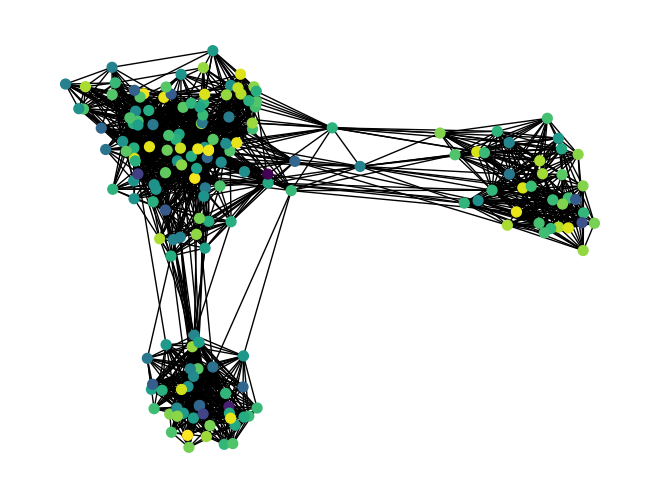

In [11]:
pos = nx.spring_layout(landscape.graph, seed=2)
nx.draw(landscape.graph, pos, node_color=f_km_std, node_size=50)

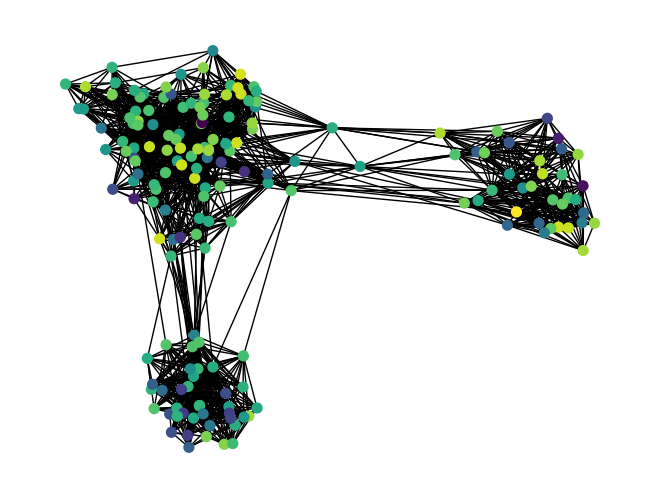

In [12]:
pos = nx.spring_layout(landscape.graph, seed=2)
nx.draw(landscape.graph, pos, node_color=f_kcat_std, node_size=50)

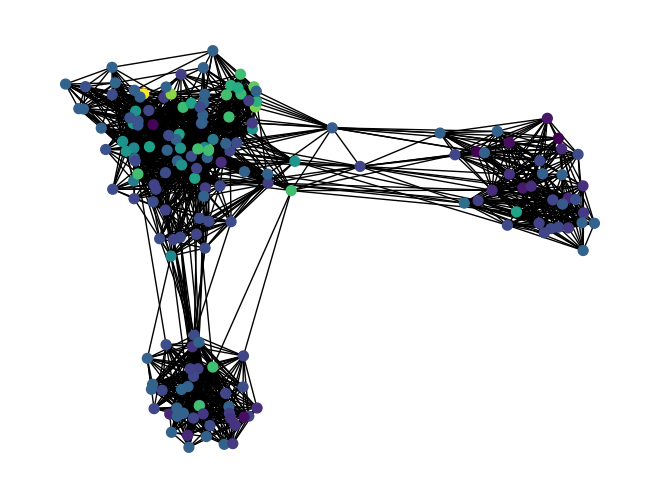

In [18]:
pos = nx.spring_layout(landscape.graph, seed=2)
nx.draw(landscape.graph, pos, node_color=f_temp_std, node_size=50)

In [41]:
df

,nt_seq,aa_seq,Nham_nt,Nham_aa,Nmut_codons,WT,indel,STOP,STOP_readthrough,count_e1_s0,...,fold_6_additive_trait0,fold_6_additive_trait1,fold_7_additive_trait0,fold_7_additive_trait1,fold_8_additive_trait0,fold_8_additive_trait1,fold_9_additive_trait0,fold_9_additive_trait1,fold_10_additive_trait0,fold_10_additive_trait1
0,NaN,TLMVALYDYEARTEDDLSLHKGEKLQVLNSSEGDWWEARSLTTGET...,NaN,6,NaN,NaN,True,False,False,50,...,-1.140065,0.000000,-1.201854,0.000000,-1.129400,0.000000,-1.071019,0.000000,-1.112196,0.000000
1,NaN,TLMVALYDYEARTEDDLSFHKGEKLQILNSSEGDWWEARSLTTGET...,NaN,4,NaN,NaN,True,False,False,36,...,-0.646269,0.000000,-0.776035,0.000000,-0.916472,0.000000,-0.712225,0.000000,-0.746408,0.000000
2,NaN,TLMVALYDYEARTEDDMSFHKGEKLQILNSSEGDWWEARSLTTGET...,NaN,5,NaN,NaN,True,False,False,224,...,-1.436442,0.000000,-1.391968,0.000000,-1.276900,0.000000,-1.114675,0.000000,-1.328760,0.000000
3,NaN,TLFVALYDYEARTEDDMSLHKGEKIQVLNSSEGDWWEARSLTTGET...,NaN,6,NaN,NaN,True,False,False,64,...,-1.471780,0.000000,-1.289315,0.000000,-1.287930,0.000000,-1.493988,0.000000,-1.435245,0.000000
4,NaN,TLMVALYDYEARTEDDFSFHKGEKFQVLNSSEGDWWEARSLTTGET...,NaN,4,NaN,NaN,True,False,False,67,...,-1.142168,0.000000,-1.094820,0.000000,-0.991572,0.000000,-1.251485,0.000000,-1.010749,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55449,NaN,TLIVALYDYEARTEDDVSLHKGEKIQLLNSSEGDWWEARSLTTGET...,NaN,7,NaN,NaN,False,False,False,48,...,6.562960,-1.120922,5.839266,-0.810607,6.173780,-0.836460,6.588972,-0.857354,6.863733,-1.314934
55450,NaN,TLIVALYDYEARTEDDVSIHKGEKMQVLNSSEGDWWEARSLTTGET...,NaN,7,NaN,NaN,False,False,False,51,...,5.272690,-0.204205,5.181114,-0.163887,4.804933,0.000644,4.955433,0.167822,5.029876,0.119946
55451,NaN,TLLVALYDYEARTEDDFSVHKGEKVQLLNSSEGDWWEARSLTTGET...,NaN,7,NaN,NaN,False,False,False,110,...,4.481658,1.227767,3.999045,2.138802,4.354357,1.260778,4.303632,1.414329,4.195873,1.480505
55452,NaN,TLIVALYDYEARTEDDFSMHKGEKLQFLNSSEGDWWEARSLTTGET...,NaN,6,NaN,NaN,False,False,False,60,...,6.226844,-0.792261,5.444471,-0.422868,6.571077,-1.674054,6.509073,-1.593420,5.455229,0.296510


### Folding and binding landscape

In [2]:
df = pd.read_csv('../data_files/combinatorial_core/predicted_phenotypes_all.csv')
sequences = [fl.BaseNumpySequence(sequence) for sequence in df['aa_seq']]

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)

/var/folders/dm/sqfv0msd3g50txf84szl1c4m0000gn/T/ipykernel_25649/1896168244.py:1: DtypeWarning: Columns (0: WT, 1: Protein, 2: wt_core) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data_files/combinatorial_core/predicted_phenotypes_all.csv')


: 

In [ ]:
# Phenotype 1 folds, phenotype 2 folds + binds
phenotype_cat = np.array(df['phenotype'])

# Binding and folding categories
binding_cat = np.array(df['Binding'])
folding_cat = np.array(df['Abundance'])

# Numeric composite fitness and S.D
fitness_comp = np.array()

array([1, 1, 1, ..., 2, 2, 2], shape=(55454,))

### Below is broken / incorrect - keep for reference only.

In [2]:

# Load folding landscape
df_folding = pd.read_csv('../data_files/combinatorial_core/FYN_folding_fitness.csv')

# Load binding landscape
df_binding = pd.read_csv('../data_files/combinatorial_core/FYN_binding_fitness.csv')

# Inner join to keep only sequences found in both assays
df_intersect = pd.merge(
    df_binding, 
    df_folding, 
    on='sequence', 
    how='inner', 
    suffixes=('_bind', '_fold')
)

df_intersect.dropna(inplace=True)

sequences = [fl.BaseNumpySequence(sequence) for sequence in df_intersect['sequence']]
fintess_binding = np.array(df_intersect['fitness_bind'])
fitness_folding = np.array(df_intersect['fitness_fold'])

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)


landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)

landscape = landscape.get_components()[0]


# Precompute eigenpairs.
eigenvals, eigenvecs = fl.transforms.eigenmode_decomposition(landscape, matrix='norm_laplacian')

/Users/matthewspence/Documents/Documents/graph-ruggedness-de/.env/lib/python3.12/site-packages/fitness_landscape/transforms/eigenmode.py:87: RuntimeWarning: Computing all eigenpairs for a large graph; this may be slow or memory-intensive. Pass k to compute a truncated basis instead.
  warnings.warn(


In [3]:
# Load folding landscape
df_folding = pd.read_csv('../data_files/combinatorial_core/FYN_folding_fitness.csv')

# Load binding landscape
df_binding = pd.read_csv('../data_files/combinatorial_core/FYN_binding_fitness.csv')

# Inner join to keep only sequences found in both assays
df_intersect = pd.merge(
    df_binding, 
    df_folding, 
    on='sequence', 
    how='inner', 
    suffixes=('_bind', '_fold')
)

df_intersect.dropna(inplace=True)

sequences = [fl.BaseNumpySequence(sequence) for sequence in df_intersect['sequence']]
fintess_binding = np.array(df_intersect['fitness_bind'])
fitness_folding = np.array(df_intersect['fitness_fold'])

# Scale K to sqrt of number of sequences
knn_k = max(int(np.sqrt(len(sequences))), 2)

# Construct fitness landscape
landscape = fl.FitnessLandscape.build(
    sequences,
    graph="hamming",
)

f_bind_std = zscore(fintess_binding)
f_fold_std = zscore(fitness_folding)


# Regress binding against folding.
slope, intercept, r_value, p_value, std_err = linregress(f_fold_std, f_bind_std)
f_bind_pred = intercept + slope * f_fold_std
f_residuals = f_bind_std - f_bind_pred
f_residuals_std = zscore(f_residuals)

# Attach residuals
landscape.attach(name="binding_residuals_std", values=f_residuals_std, dtype="numeric")

# Attach and analyze Binding
landscape.attach(name="binding_fitness_std", values=f_bind_std, dtype="numeric")

# Attach and analyze Folding
landscape.attach(name="folding_fitness_std", values=f_fold_std, dtype="numeric")

# Get landscape components.
landscape = landscape.get_components()[0]


# Compute ruggedness
# Binding
landscape.view("binding_fitness_std")
tmap_res_binding = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, _eigenvalues=eigenvals, _eigenvectors=eigenvecs, prior='uniform'
)
binding_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)

# Folding
landscape.view("folding_fitness_std")
tmap_res_folding = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, _eigenvalues=eigenvals, _eigenvectors=eigenvecs, prior='uniform'
)
folding_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)

# Residual
landscape.view("binding_residuals_std")
tmap_res_residual = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(
    landscape, t_min=1e-10, t_max=1e2, _eigenvalues=eigenvals, _eigenvectors=eigenvecs, prior='uniform'
)
residual_energy = fl.analysis.dirichlet_energy.calculate_ruggedness_dirichlet_energy(landscape)

In [97]:
tmap_res_folding

{'t_map': 2.6706346621560515,
 't_lower_confidence_interval': 2.533676678863842,
 't_upper_confidence_interval': 2.6857669359775334,
 't_logposterior_map': -8525.767929683663,
 'variance_approximate': 0.0005958855386161526}

In [100]:
tmap_res_residual

{'t_map': 2.3968880463189777,
 't_lower_confidence_interval': 2.2738435747879455,
 't_upper_confidence_interval': 2.393733061324879,
 't_logposterior_map': -9240.413732412495,
 'variance_approximate': 4.4873777960043766e-06}

In [6]:
# Moran's I test

f_high_res = landscape.fitness_layers['binding_residuals_std'].to_scalar()

G = landscape.graph

# Calculate Node-wise 'Ruggedness Power' (Local Dirichlet Energy on edges)
node_to_val = {node: val for node, val in zip(G.nodes(), f_high_res)}
node_energy = {u: np.sum([(node_to_val[u] - node_to_val[v])**2 for v in G.neighbors(u)]) 
                for u in G.nodes()}

# I > 0: Clustered (Ruggedness is localized at boundaries)
# I = 0: Random (Ruggedness is a uniform noise floor)
# I < 0: Dispersed
energy_vec = np.array([node_energy[n] for n in G.nodes()])
W = nx.adjacency_matrix(G).toarray()

# Standard Moran's I calculation
z = energy_vec - np.mean(energy_vec)
moran_i = (len(z) * (z @ W @ z)) / (np.sum(W) * (z @ z))

# Significance via Permutation
null_is = []
for _ in range(500):
    shuffled_z = np.random.permutation(z)
    null_is.append((len(z) * (shuffled_z @ W @ shuffled_z)) / (np.sum(W) * (shuffled_z @ shuffled_z)))

p_val = np.sum(np.array(null_is) >= moran_i) / 500


In [34]:
# collect index ordered sequence and signals

sequences = [node[1]['sequence'].to_str() for node in landscape.graph.nodes(data=True)]
f_residuals_std_sig = landscape.fitness_layers['binding_residuals_std'].to_scalar()

In [35]:


# 1. Setup Parser and Map 3-letter to 1-letter codes
parser = Bio.PDB.PDBParser(QUIET=True)
structure = parser.get_structure('5ZAU', 'pdb5zau.ent')
model = structure[0]
chain = model['A']

d3to1 = {
    'ALA': 'A', 'CYS': 'C', 'ASP': 'D', 'GLU': 'E', 'PHE': 'F', 
    'GLY': 'G', 'HIS': 'H', 'ILE': 'I', 'LYS': 'K', 'LEU': 'L', 
    'MET': 'M', 'ASN': 'N', 'PRO': 'P', 'GLN': 'Q', 'ARG': 'R', 
    'SER': 'S', 'THR': 'T', 'VAL': 'V', 'TRP': 'W', 'TYR': 'Y'
}

# 2. Extract WT Sequence and Residue List
res_list = []
wt_seq_chars = []
for res in chain.get_residues():
    resname = res.get_resname()
    if Bio.PDB.is_aa(res) and resname in d3to1:
        res_list.append(res)
        wt_seq_chars.append(d3to1[resname])

wt_seq = "".join(wt_seq_chars)

# 3. Map your 'energy_vec' to Residue Positions
# This assumes 'sequences' is your list of fl.BaseNumpySequence objects
residue_energies = np.zeros(len(wt_seq))
residue_counts = np.zeros(len(wt_seq))

# We use your 'energy_vec' from the Moran's I step
for mut_seq, energy in zip(sequences, energy_vec):
    mut_seq
    # Map energy to every site that differs from WT
    for i in range(min(len(wt_seq), len(mut_seq))):
        if mut_seq[i] != wt_seq[i]:
            residue_energies[i] += energy
            residue_counts[i] += 1

# Average per residue and normalize for coloring
avg_res_energy = np.divide(residue_energies, residue_counts, 
                           out=np.zeros_like(residue_energies), 
                           where=residue_counts!=0)

norm_energy = (avg_res_energy - avg_res_energy.min()) / (avg_res_energy.max() - avg_res_energy.min() + 1e-9)

# 4. Interactive 3D Visualization
view = py3Dmol.view(query='pdb:5zau')
view.setStyle({'cartoon': {'color': 'white'}})

for i, energy_val in enumerate(norm_energy):
    # Color scale: Blue (Low Energy/Smooth) to Red (High Energy/Rugged)
    red = int(255 * energy_val)
    blue = int(255 * (1 - energy_val))
    hex_color = f'0x{red:02x}00{blue:02x}'
    
    res_num = res_list[i].get_id()[1]
    view.addStyle({'chain': 'A', 'resi': res_num}, 
                  {'cartoon': {'color': hex_color}, 'stick': {'color': hex_color}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

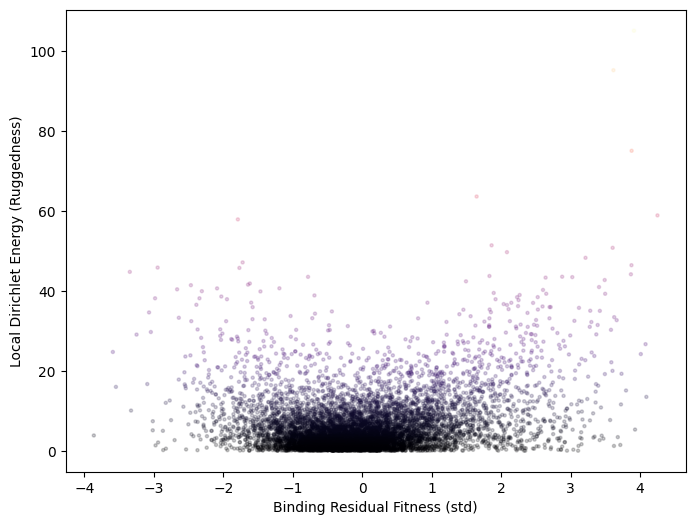

In [37]:


# Plot 1: Standardized Fitness vs. Local Energy
plt.figure(figsize=(8, 6))
plt.scatter(f_residuals_std_sig, energy_vec, alpha=0.2, s=5, c=energy_vec, cmap='magma')
plt.xlabel("Binding Residual Fitness (std)")
plt.ylabel("Local Dirichlet Energy (Ruggedness)")
plt.show()